# LungCT Registration — Robustness Under Systemic Error
**Course:** IN2022 Computer-Aided Medical Procedures II, SS 2026  
**Task:** Learn2reg LungCT Registration — uniGradICON  
**Author:** Wala Hasnaoui

## What this notebook does
1. Loads the Learn2reg LungCT dataset (all 20 pairs)
2. Runs uniGradICON baseline inference
3. Applies FOV truncation corruption (middle region slices 60-130)
4. Applies Reference-based Inpainting fix
5. Compares metrics: Similarity Loss (LNCC), Folded Voxels, TRE

## Key finding
FOV truncation in the mid-lung region (where landmarks are located) 
severely degrades registration quality. Reference-based inpainting 
using the fixed image restores performance close to baseline.

In [5]:
import sys
sys.path.insert(0, "D:/camp 2 project/uniGradICON/src")

import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-e", "D:/camp 2 project/uniGradICON", "-q"])


CompletedProcess(args=['c:\\Users\\walah\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', '-m', 'pip', 'install', '-e', 'D:/camp 2 project/uniGradICON', '-q'], returncode=0)

In [6]:


import torch
import itk
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from unigradicon import get_unigradicon

torch.set_num_threads(2)

DATA = "D:/camp 2 project/dataset/LungCT/LungCT"
PAIRS_ALL = [f"{i:04d}" for i in range(1, 21)]  # all 20 pairs
PAIRS_LANDMARKS = ["0001", "0002", "0003"]  # manual landmarks only

print(f"Total pairs: {len(PAIRS_ALL)}")
print(f"Pairs with manual landmarks: {PAIRS_LANDMARKS}")

Total pairs: 20
Pairs with manual landmarks: ['0001', '0002', '0003']


In [7]:
def load_image_torch(path):
    img = itk.imread(path, itk.F)
    arr = itk.array_from_image(img)
    tensor = torch.tensor(arr).unsqueeze(0).unsqueeze(0)
    tensor = F.interpolate(tensor, size=(175, 175, 175), mode='trilinear', align_corners=False)
    tensor = (tensor - tensor.min()) / (tensor.max() - tensor.min())
    return tensor

def load_landmarks(path):
    return np.loadtxt(path, delimiter=',')

def compute_tre(fixed_lm, moving_lm):
    dists = [np.sqrt(np.sum((fixed_lm[i] - moving_lm[i])**2)) 
             for i in range(len(fixed_lm))]
    return np.mean(dists)

def corrupt_fov_middle(tensor, start=60, end=130):
    corrupted = tensor.clone()
    corrupted[:, :, start:end, :, :] = 0
    return corrupted

def fix_from_reference(corrupted_moving, fixed_image, start=60, end=130):
    fixed = corrupted_moving.clone()
    fixed[:, :, start:end, :, :] = fixed_image[:, :, start:end, :, :]
    return fixed

print("Helper functions loaded.")


Helper functions loaded.


In [8]:
model = get_unigradicon()
model.eval()
print("Model loaded.")

Model loaded.


In [9]:
baseline_results = {}

for pair in PAIRS_ALL:
    fixed_t = load_image_torch(f"{DATA}/imagesTr/LungCT_{pair}_0000.nii.gz")
    moving_t = load_image_torch(f"{DATA}/imagesTr/LungCT_{pair}_0001.nii.gz")
    
    # TRE before (using keypoints for all pairs)
    kp_fixed = load_landmarks(f"{DATA}/keypointsTr/LungCT_{pair}_0000.csv")
    kp_moving = load_landmarks(f"{DATA}/keypointsTr/LungCT_{pair}_0001.csv")
    tre_before = compute_tre(kp_fixed, kp_moving)
    
    with torch.no_grad():
        phi = model(moving_t, fixed_t, moving_t, fixed_t)
    
    baseline_results[pair] = {
        "tre_before": tre_before,
        "sim": phi.similarity_loss.item(),
        "flips": phi.flips.item()
    }
    print(f"Pair {pair}: TRE before={tre_before:.2f}mm | sim={phi.similarity_loss.item():.4f} | flips={phi.flips.item():.0f}")

print("\nBaseline done!")

Pair 0001: TRE before=14.69mm | sim=0.9114 | flips=5267
Pair 0002: TRE before=10.87mm | sim=0.6528 | flips=1325
Pair 0003: TRE before=5.99mm | sim=0.8049 | flips=1686
Pair 0004: TRE before=3.94mm | sim=0.7391 | flips=125
Pair 0005: TRE before=9.53mm | sim=0.6930 | flips=258
Pair 0006: TRE before=9.61mm | sim=0.6767 | flips=3077
Pair 0007: TRE before=5.34mm | sim=0.7423 | flips=5375
Pair 0008: TRE before=8.68mm | sim=0.8508 | flips=3711
Pair 0009: TRE before=10.78mm | sim=0.5736 | flips=344
Pair 0010: TRE before=5.22mm | sim=0.8335 | flips=1831
Pair 0011: TRE before=5.44mm | sim=0.6707 | flips=1104
Pair 0012: TRE before=7.66mm | sim=0.6540 | flips=904
Pair 0013: TRE before=5.08mm | sim=0.6763 | flips=1633
Pair 0014: TRE before=6.33mm | sim=0.6557 | flips=500
Pair 0015: TRE before=5.88mm | sim=0.7804 | flips=3452
Pair 0016: TRE before=2.46mm | sim=0.8776 | flips=146
Pair 0017: TRE before=14.25mm | sim=0.8251 | flips=2108
Pair 0018: TRE before=2.70mm | sim=0.8380 | flips=4
Pair 0019: TRE 

In [10]:
corrupted_results = {}

for pair in PAIRS_ALL:
    fixed_t = load_image_torch(f"{DATA}/imagesTr/LungCT_{pair}_0000.nii.gz")
    moving_t = load_image_torch(f"{DATA}/imagesTr/LungCT_{pair}_0001.nii.gz")
    
    kp_fixed = load_landmarks(f"{DATA}/keypointsTr/LungCT_{pair}_0000.csv")
    kp_moving = load_landmarks(f"{DATA}/keypointsTr/LungCT_{pair}_0001.csv")
    tre_before = compute_tre(kp_fixed, kp_moving)
    
    fixed_c = corrupt_fov_middle(fixed_t)
    moving_c = corrupt_fov_middle(moving_t)
    
    with torch.no_grad():
        phi = model(moving_c, fixed_c, moving_c, fixed_c)
    
    corrupted_results[pair] = {
        "tre_before": tre_before,
        "sim": phi.similarity_loss.item(),
        "flips": phi.flips.item()
    }
    print(f"Pair {pair}: TRE before={tre_before:.2f}mm | sim={phi.similarity_loss.item():.4f} | flips={phi.flips.item():.0f}")

print("\nCorruption done!")

Pair 0001: TRE before=14.69mm | sim=1.6336 | flips=30284
Pair 0002: TRE before=10.87mm | sim=1.1559 | flips=39449
Pair 0003: TRE before=5.99mm | sim=1.2551 | flips=9504
Pair 0004: TRE before=3.94mm | sim=1.4078 | flips=0
Pair 0005: TRE before=9.53mm | sim=1.1081 | flips=1711
Pair 0006: TRE before=9.61mm | sim=1.3506 | flips=13204
Pair 0007: TRE before=5.34mm | sim=1.2878 | flips=19364
Pair 0008: TRE before=8.68mm | sim=1.3489 | flips=7603
Pair 0009: TRE before=10.78mm | sim=1.0033 | flips=1221
Pair 0010: TRE before=5.22mm | sim=1.4721 | flips=364
Pair 0011: TRE before=5.44mm | sim=1.3944 | flips=76
Pair 0012: TRE before=7.66mm | sim=1.1820 | flips=10123
Pair 0013: TRE before=5.08mm | sim=1.3947 | flips=736
Pair 0014: TRE before=6.33mm | sim=1.1130 | flips=4873
Pair 0015: TRE before=5.88mm | sim=1.4225 | flips=39445
Pair 0016: TRE before=2.46mm | sim=1.5285 | flips=748
Pair 0017: TRE before=14.25mm | sim=1.4272 | flips=0
Pair 0018: TRE before=2.70mm | sim=1.5186 | flips=1
Pair 0019: TRE

In [12]:
fixed_results = {}

for pair in PAIRS_ALL:
    fixed_t = load_image_torch(f"{DATA}/imagesTr/LungCT_{pair}_0000.nii.gz")
    moving_t = load_image_torch(f"{DATA}/imagesTr/LungCT_{pair}_0001.nii.gz")
    
    kp_fixed = load_landmarks(f"{DATA}/keypointsTr/LungCT_{pair}_0000.csv")
    kp_moving = load_landmarks(f"{DATA}/keypointsTr/LungCT_{pair}_0001.csv")
    tre_before = compute_tre(kp_fixed, kp_moving)
    
    moving_c = corrupt_fov_middle(moving_t)
    moving_fixed = fix_from_reference(moving_c, fixed_t)
    
    with torch.no_grad():
        phi = model(moving_fixed, fixed_t, moving_fixed, fixed_t)
    
    fixed_results[pair] = {
        "tre_before": tre_before,
        "sim": phi.similarity_loss.item(),
        "flips": phi.flips.item()
    }
    print(f"Pair {pair}: TRE before={tre_before:.2f}mm | sim={phi.similarity_loss.item():.4f} | flips={phi.flips.item():.0f}")

print("\nFix done!")

Pair 0001: TRE before=14.69mm | sim=0.9031 | flips=7097
Pair 0002: TRE before=10.87mm | sim=0.5833 | flips=1273
Pair 0003: TRE before=5.99mm | sim=0.7637 | flips=2123
Pair 0004: TRE before=3.94mm | sim=0.7551 | flips=19105
Pair 0005: TRE before=9.53mm | sim=0.5933 | flips=104
Pair 0006: TRE before=9.61mm | sim=0.6072 | flips=1191
Pair 0007: TRE before=5.34mm | sim=0.7124 | flips=6141
Pair 0008: TRE before=8.68mm | sim=0.8159 | flips=3019
Pair 0009: TRE before=10.78mm | sim=0.4747 | flips=858
Pair 0010: TRE before=5.22mm | sim=0.8536 | flips=83596
Pair 0011: TRE before=5.44mm | sim=0.6690 | flips=1168
Pair 0012: TRE before=7.66mm | sim=0.6125 | flips=302
Pair 0013: TRE before=5.08mm | sim=0.6843 | flips=1310
Pair 0014: TRE before=6.33mm | sim=0.5915 | flips=251
Pair 0015: TRE before=5.88mm | sim=0.7675 | flips=4470
Pair 0016: TRE before=2.46mm | sim=0.8734 | flips=287
Pair 0017: TRE before=14.25mm | sim=0.8162 | flips=3515
Pair 0018: TRE before=2.70mm | sim=0.8243 | flips=176
Pair 0019:


Pair 0001 — Baseline:


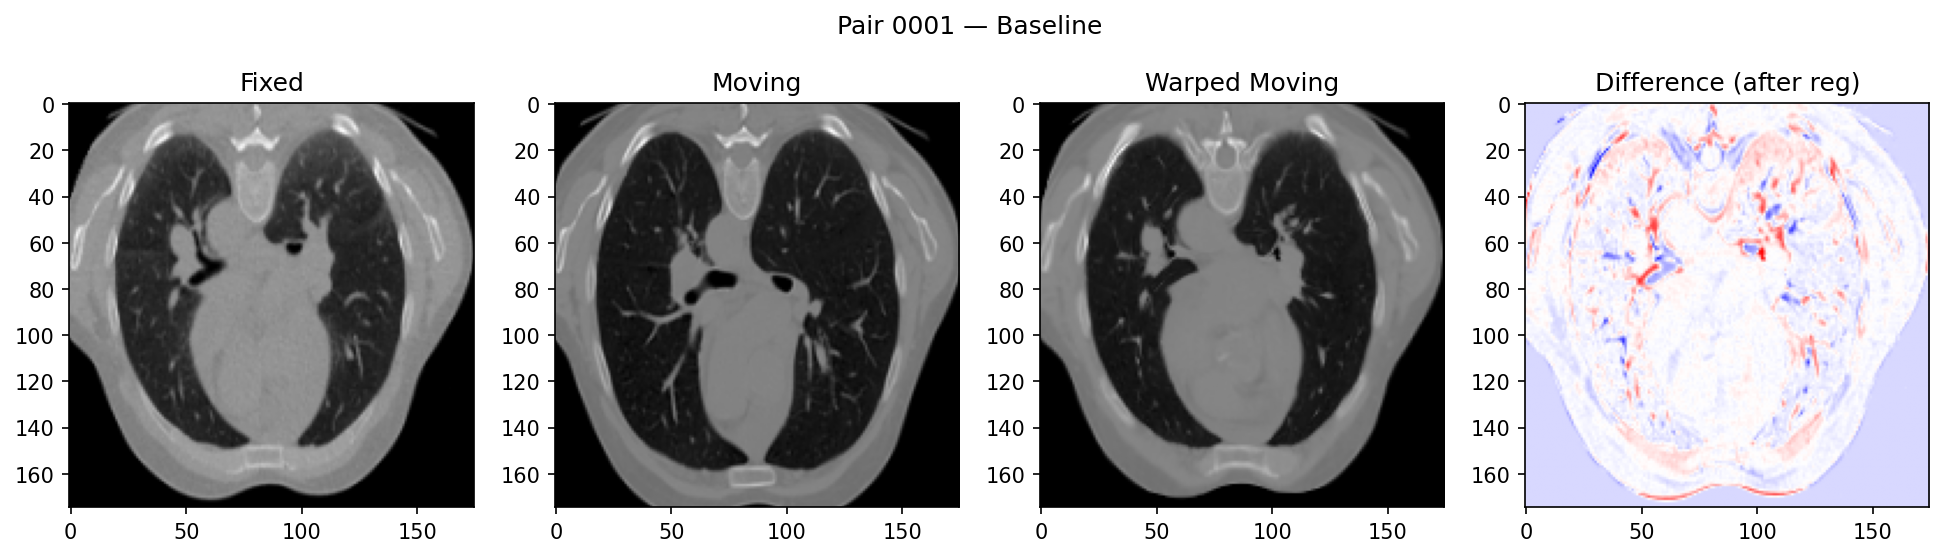


Pair 0001 — Fixed:


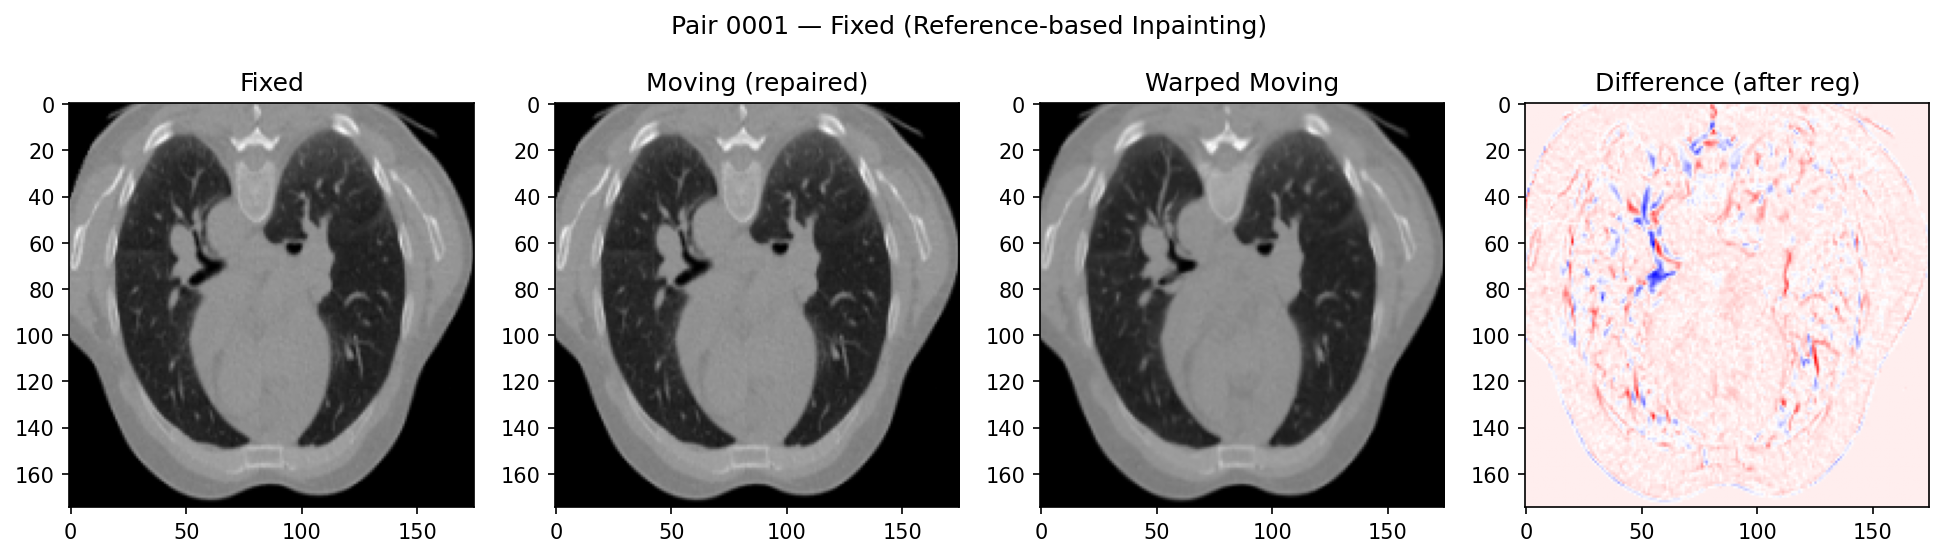


Pair 0002 — Baseline:


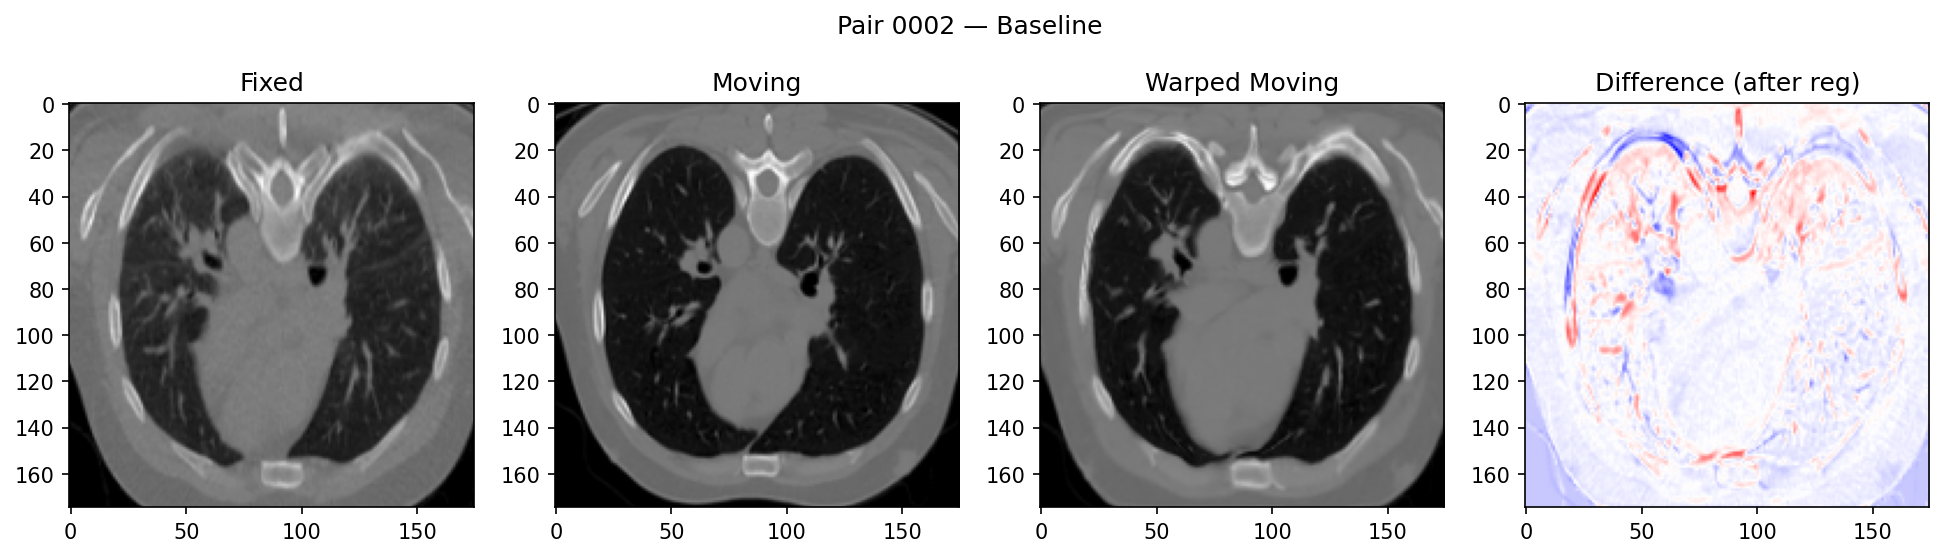


Pair 0002 — Fixed:


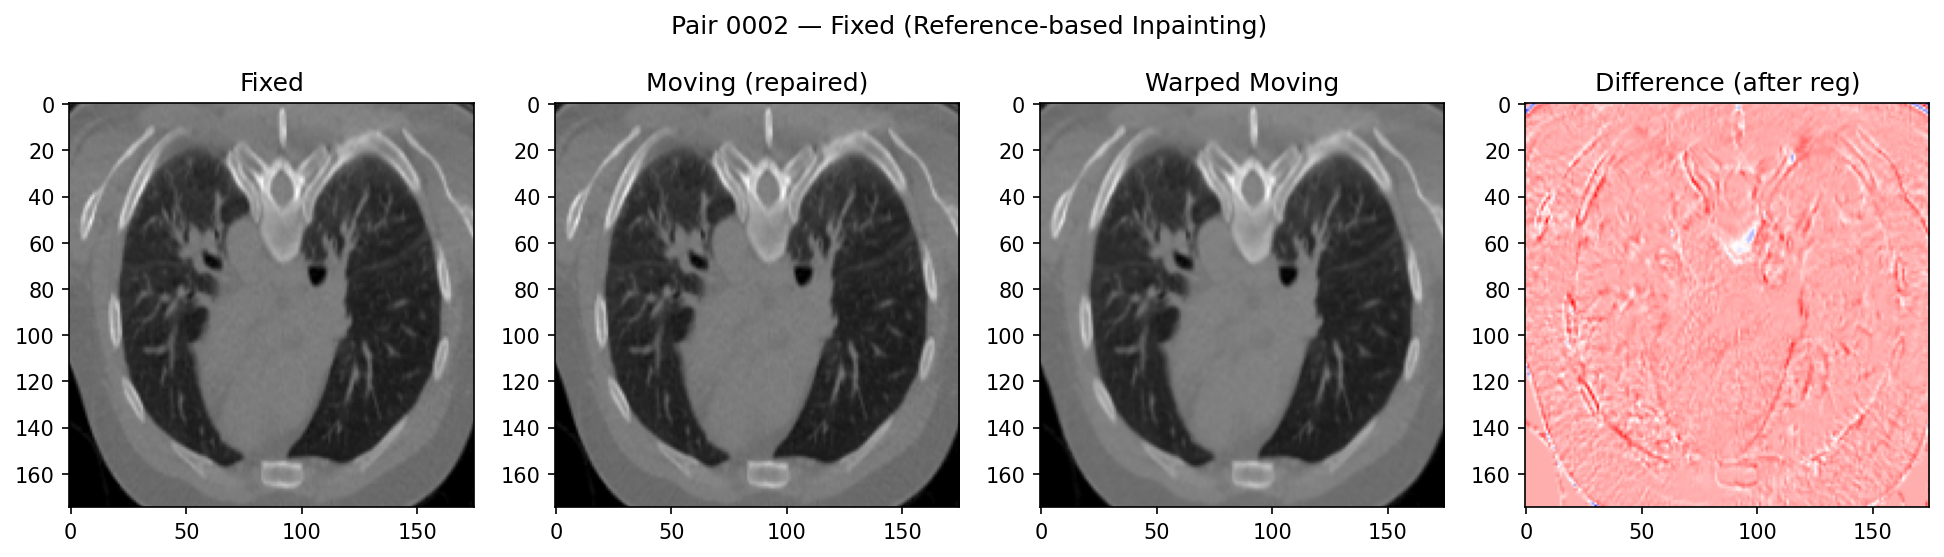


Pair 0003 — Baseline:


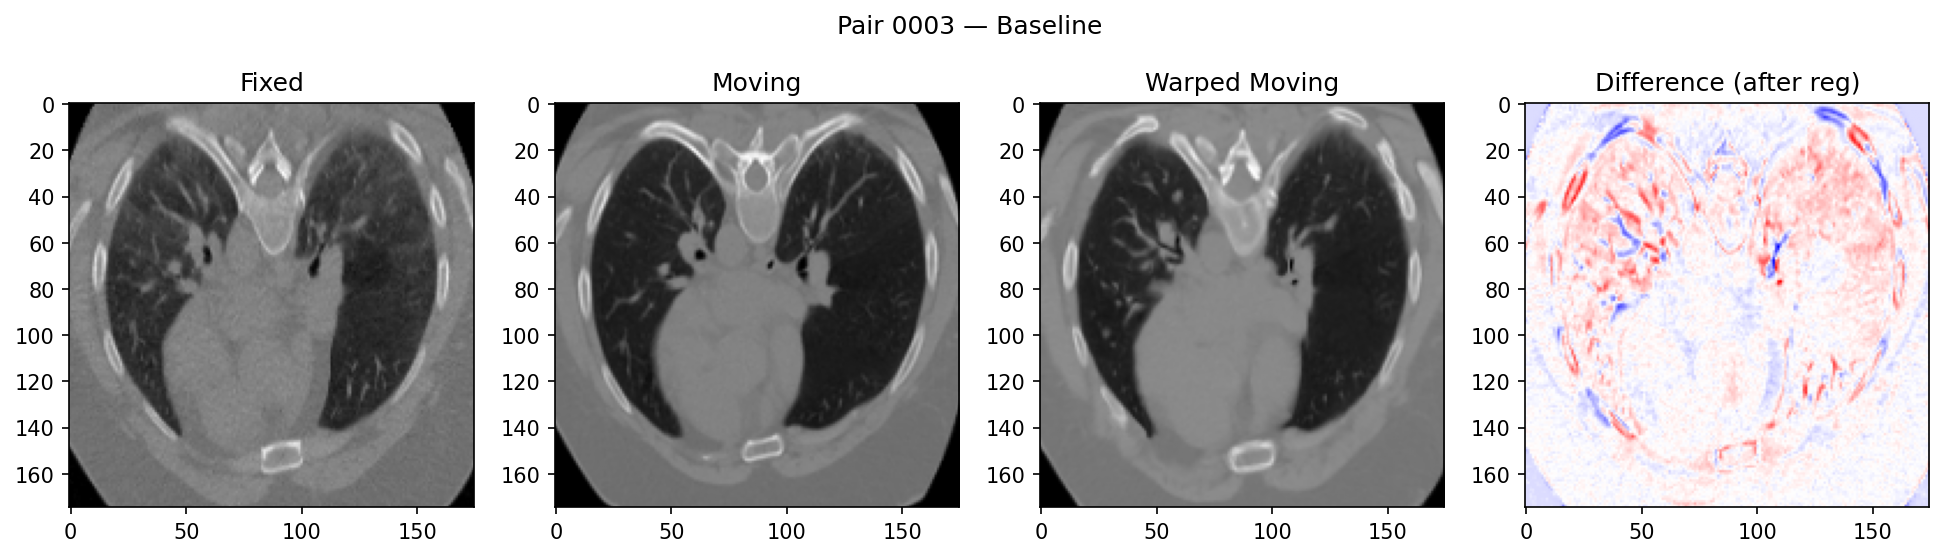


Pair 0003 — Fixed:


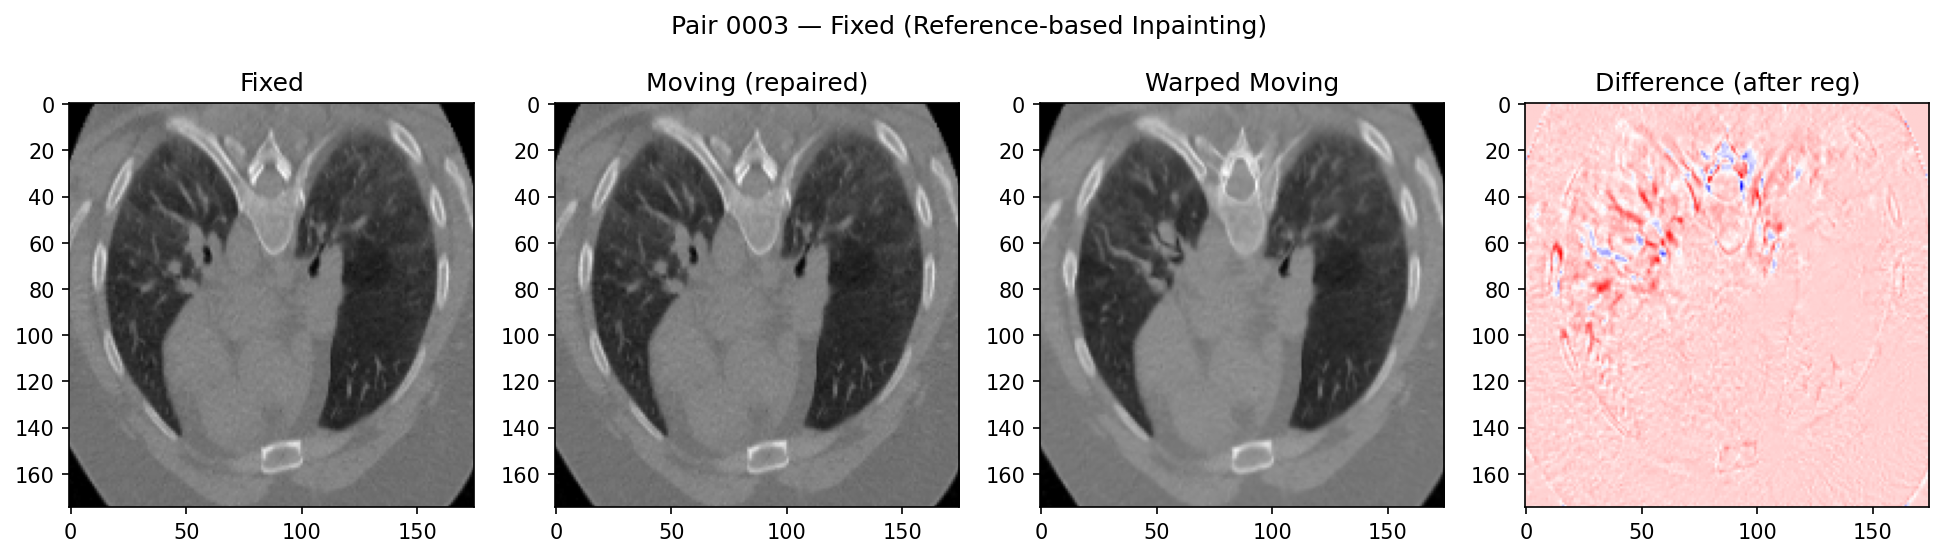

In [13]:
from IPython.display import Image, display

# Show baseline results
for pair in ["0001", "0002", "0003"]:
    print(f"\nPair {pair} — Baseline:")
    display(Image(filename=f"D:/camp 2 project/uniGradICON/results/baseline_pair{pair}.png", width=900))
    print(f"\nPair {pair} — Fixed:")
    display(Image(filename=f"D:/camp 2 project/uniGradICON/results/fov_v2_fixed_pair{pair}.png", width=900))